# Separación del conjunto de proteínas en positivas y negativas

Vamos a hacer primero una distribución gráfica de todos nuestros datos y luego a reevaluar si el umbral que hemos puesto es correcto o no.

Cargamos los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

interactions = pd.read_csv("/home/jovyan/TFG/Interacciones_EffectorProteina_LiteratureOnly_Ordenadas_NleG.csv")
interactions.head()

,Effector,Protein,ProteinGeneName,Shared_Connections,Shortest_Path,Is_Connected
0,EspL,O89110,Casp8,4,1.0,True
1,EspL,Q60855,Ripk1,3,1.0,True
2,NleB,O89110,Casp8,2,1.0,True
3,NleA,Q8R4B8,Nlrp3,1,1.0,True
4,NleA,Q9D8T2,Gsdmd,1,1.0,True


In [2]:
# Función de dibujo de las distribuciones de grupos entre parejas positivas y negativas
def draw_group_distribution(pos_groups_freq, neg_groups_freq, figure_name='distribucion_grupos_pos_neg_train.png', pos_color='green', neg_color='red',
                           title='Interacciones entre grupos representadas en positive y negative train sets', x_label='Grupos interaccionando'):
    
    # Unfy them in one unique data frame
    df_plot = pd.DataFrame({
        'Positivas': pos_groups_freq,
        'Negativas': neg_groups_freq
    }).fillna(0)
    
    df_plot = df_plot.sort_values(by='Positivas', ascending=False)
    
    # Draw the two distributions as a histogram
    plt.figure(figsize=(20, 10))
    x = range(len(df_plot))
    width = 0.4
    plt.bar(x, df_plot['Positivas'], width=width, label='Positivas', color=pos_color, alpha=0.5)
    plt.bar([i + width for i in x], df_plot['Negativas'], width=width, label='Negativas', color=neg_color)
    plt.xticks([i + width/2 for i in x], df_plot.index, rotation=90, size=10)
    #plt.yticks(np.arange(min(df_plot['Negativas']), max(df_plot['Positivas'])+1, 2)) 
    plt.title(title, size=25)
    plt.xlabel(x_label, size=20)
    plt.ylabel('Frecuencia', size=20)
    plt.legend(fontsize=20)
    plt.grid(axis='y', alpha=0.5)
    plt.savefig(figure_name, dpi=300, bbox_inches='tight')
    plt.show()

Repetimos con el nuevo csv de interacciones ordenados por un índice de mayor probabilidad de interacción calculado a partir del grafo extendido.

In [5]:
new_interactions = pd.read_csv("/home/jovyan/TFG/Interacciones_EffectorProteina_LiteratureExtended_Ordenadas.csv", sep=';')
new_interactions.head()
new_interactions

,Effector,Protein,Shortest_Path,Shared_Connections,Pathways_Shared,Is_Connected,Interaction_Score
0,NleD,Mapk14,1,13,1,True,0.603571
1,EspM,Rhoc,1,3,3,True,0.539286
2,NleB,Ripk1,1,13,0,True,0.528571
3,NleB,Nfkb1,1,2,3,True,0.517857
4,EspH,Rac2,1,2,3,True,0.517857
...,...,...,...,...,...,...,...
5125,NleG8,Tmbim6,6,0,0,False,0.000000
5126,NleG8,Rab17,6,0,0,False,0.000000
5127,NleG8,Rab11b,6,0,0,False,0.000000
5128,NleG8,Rab11fip3,6,0,0,False,0.000000


Reseteamos los índices y eliminamos todas las parejas positivas.

In [7]:
new_interactions_no_pos = new_interactions[new_interactions['Is_Connected']==False]
new_interactions_no_pos = new_interactions_no_pos.reset_index(drop=True)
#new_interactions_no_pos.to_csv("Interacciones_EffectorProteina_LiteratureExtended_Ordenadas_no_pos.csv", index=False)
new_interactions_no_pos

,Effector,Protein,Shortest_Path,Shared_Connections,Pathways_Shared,Is_Connected,Interaction_Score
0,NleD,Map3k7,2,21,1,False,0.725
1,NleD,Il6,2,21,1,False,0.725
2,NleD,Jun,2,21,1,False,0.725
3,NleD,Ccl8,2,21,0,False,0.650
4,NleD,Ccl28,2,21,0,False,0.650
...,...,...,...,...,...,...,...
4908,NleG8,Tmbim6,6,0,0,False,0.000
4909,NleG8,Rab17,6,0,0,False,0.000
4910,NleG8,Rab11b,6,0,0,False,0.000
4911,NleG8,Rab11fip3,6,0,0,False,0.000


/tmp/ipykernel_2584/595818526.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(0, q2, color='gray', alpha=0.3, label='Zona desconocida', edgecolor='none', linewidth=0)
/tmp/ipykernel_2584/595818526.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(q2, len(new_interactions_no_pos), color='red', alpha=0.3, label='Zona Negativos', edgecolor='none', linewidth=0)


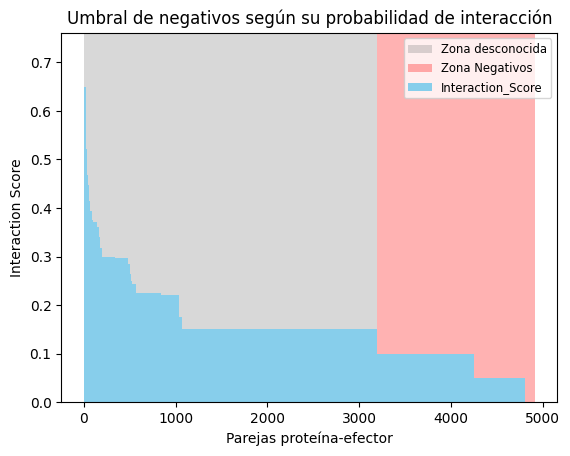

In [8]:
# Separo las interacciones positivas de las negativas
q2 = round((5130 - 217)*0.5)
q2 = 3194
negativas = new_interactions_no_pos[q2:len(new_interactions_no_pos)]
resto = new_interactions_no_pos[0:q2]
new_interactions_no_pos['id_fila'] = pd.Series(range(len(new_interactions_no_pos))).values

# Gráfico de barras
fig, ax = plt.subplots()
# Definimos los umbrales de separación de positivos y negativos
plt.vlines(x=[q2], ymin=0, ymax=0.7, colors=['r'], linestyles=['--'], alpha=0)
# Dividimos el gráfico en zonas de inciertos y negativos y lo coloreamos
ax.axvspan(0, q2, color='gray', alpha=0.3, label='Zona desconocida', edgecolor='none', linewidth=0)
ax.axvspan(q2, len(new_interactions_no_pos), color='red', alpha=0.3, label='Zona Negativos', edgecolor='none', linewidth=0)
# Dibujamos las distribuciones
ax.bar(new_interactions_no_pos['id_fila'], new_interactions_no_pos['Interaction_Score'], label='Interaction_Score', color='skyblue', width=1.0, edgecolor='none')
plt.title('Umbral de negativos según su probabilidad de interacción')
plt.ylabel('Interaction Score')
plt.xlabel('Parejas proteína-efector')
plt.legend(loc='upper right', fontsize='small')
#plt.savefig('separacion_pos_neg_index_barplot.png', dpi=600, bbox_inches='tight')
plt.show()

### Representación gráfica de las interacciones positivas

In [9]:
# Función para dibujar las frecuencias de aparición de un conjunto de nombres en un Data Frame de datos
def draw_freq(freq, title, xlabel, figure_name, font_size, title_size, ax_label_size):
    """ Función para dibujar frecuencias en formato de barplot.
    --freq: panda Series con dos columnas, nombre de los elementos a representar y frecuencia de cada uno
    --title: título del gráfico
    --xlabel: etiqueta del eje X
    --figure_name: nombre con el que se va a guardar el archivo .png con el gráfico
    --font_size: tamaño de fuente a usar en el eje X
    """
    freq = freq.sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    freq.plot.bar(color='green')
    plt.title(title, size=title_size)
    plt.xlabel(xlabel, size=ax_label_size)
    plt.ylabel('Frecuencia', size=ax_label_size)
    plt.xticks(fontsize=font_size)
    plt.grid(axis='y', alpha=0.5)
    plt.savefig(figure_name, dpi=300, bbox_inches='tight')
    plt.show()

##### Distribución de efectores individuales en el conjunto de parejas positivas

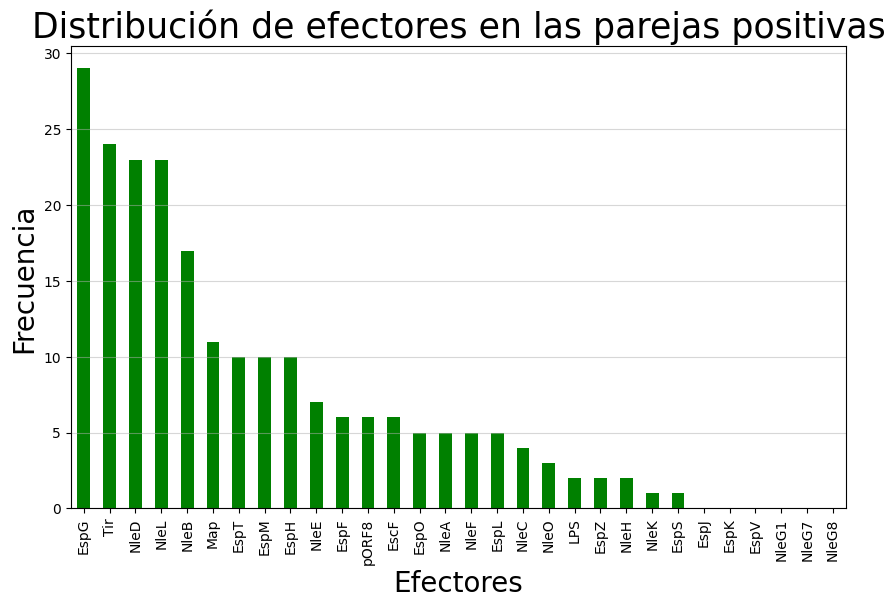

In [10]:
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
effectors = np.unique(new_interactions['Effector'])
freq_ef = pos_interactions['Effector'].value_counts()
freq_ef = freq_ef.reindex(effectors, fill_value=0)
draw_freq(freq_ef, 'Distribución de efectores en las parejas positivas', 'Efectores', 'imagenes/distribucion_ef_pos_train.png', 10, 25, 20)

##### Distribución de proteínas individuales en el conjunto de parejas positivas

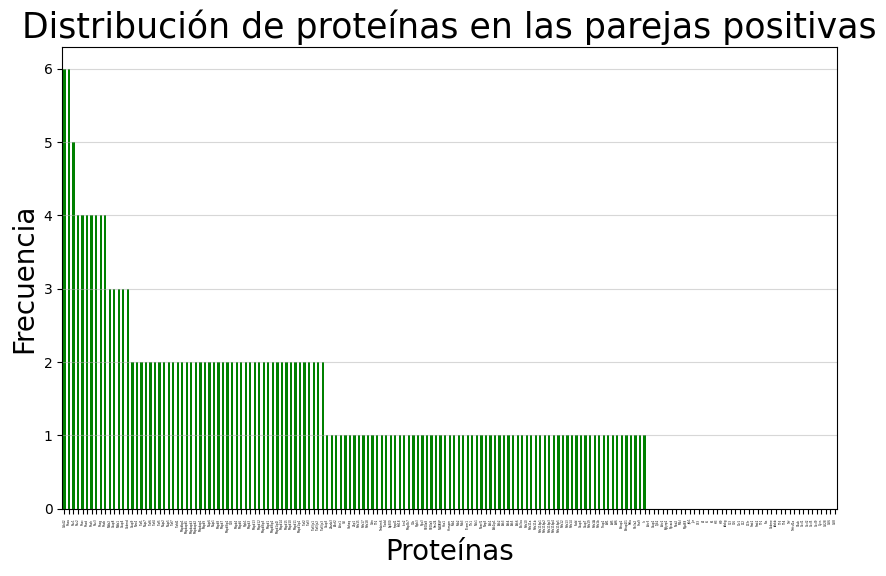

In [11]:
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
proteins = np.unique(new_interactions['Protein'])
freq_prot = pos_interactions['Protein'].value_counts()
freq_prot = freq_prot.reindex(proteins, fill_value=0)
draw_freq(freq_prot, 'Distribución de proteínas en las parejas positivas', 'Proteínas', 'imagenes/distribucion_prot_pos_train.png', 2, 25, 20)

##### Distribución de grupos de efectores en el conjunto de parejas positivas

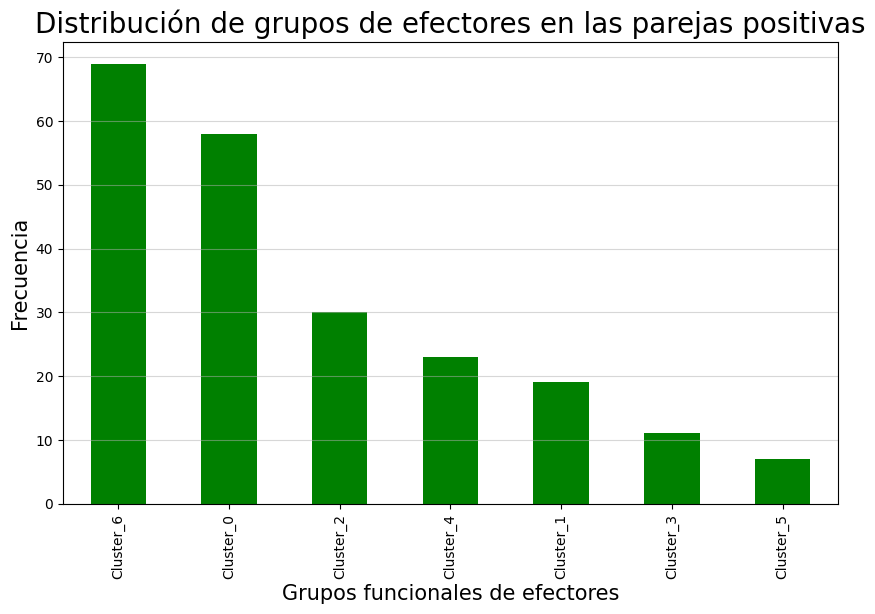

In [12]:
effector_groups = pd.read_csv("effector_groups_kmeans.csv")
mapping_ef_groups = effector_groups.set_index("Effector")["Kmeans_Group"]
new_interactions["Effector_Group"] = new_interactions["Effector"].map(mapping_ef_groups)
new_interactions = new_interactions[new_interactions["Effector_Group"] != "-"]
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
unique_ef_groups = np.unique(new_interactions['Effector_Group'])
freq_ef_group = pos_interactions['Effector_Group'].value_counts()
freq_ef_group = freq_ef_group.reindex(unique_ef_groups, fill_value=0)
draw_freq(freq_ef_group, 'Distribución de grupos de efectores en las parejas positivas', 'Grupos funcionales de efectores', 'imagenes/distribucion_grupos_ef_pos_train.png', 10, 20, 15)

##### Distribución de grupos de proteínas en el conjunto de parejas positivas

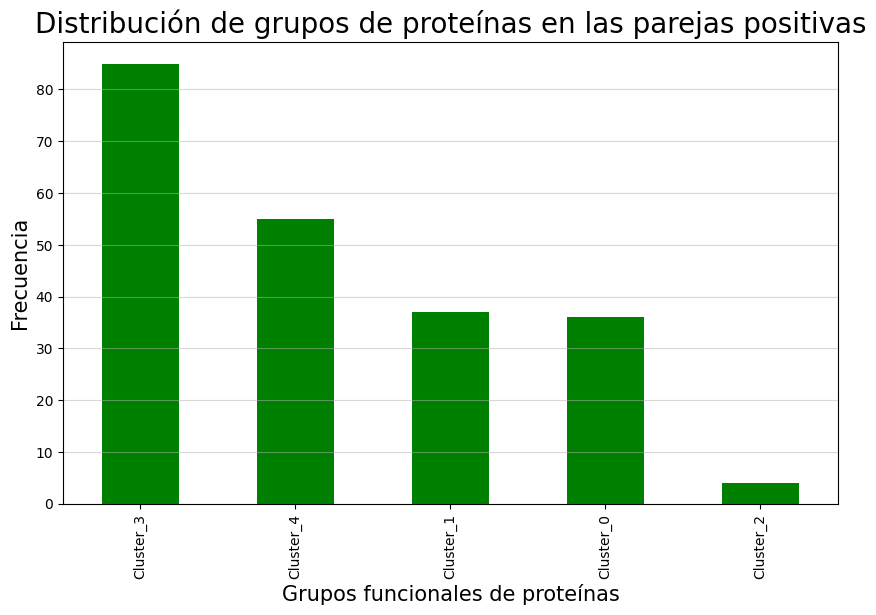

In [13]:
# Antes de mapear los nombres de las proteínas, hay que añadir sus identificadores de Uniprot
uniprot_equivalences = pd.read_csv("/home/jovyan/TFG/Interacciones_EffectorProteina_LiteratureOnly_Ordenadas_NleG.csv", sep=",")
prot_id = pd.Series(uniprot_equivalences.Protein.values, index=uniprot_equivalences.ProteinGeneName).to_dict()
new_interactions["Protein_ID"] = new_interactions["Protein"].map(prot_id)

# Ahora ya mapeamos los grupos generados por kmeans
protein_groups = pd.read_csv("protein_groups_kmeans.csv")
mapping_prot_groups = protein_groups.set_index("Protein")["Kmeans_Group"]
new_interactions["Protein_Group"] = new_interactions["Protein_ID"].map(mapping_prot_groups)
new_interactions["Protein_Group"] = new_interactions["Protein_Group"].fillna("Sin_Grupo")
new_interactions = new_interactions[new_interactions["Protein_Group"] != "Sin_Grupo"]
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
unique_prot_groups = np.unique(new_interactions['Protein_Group'])
freq_prot_group = pos_interactions['Protein_Group'].value_counts()
freq_prot_group = freq_prot_group.reindex(unique_prot_groups, fill_value=0)
if freq_prot_group.empty:
    print("¡Advertencia! El DataFrame está vacío. No se puede generar el gráfico.")
    print(f"unique_prot_groups contiene: {len(unique_prot_groups)} elementos.")
    print(f"pos_interactions tiene {len(pos_interactions)} filas.")
draw_freq(freq_prot_group, 'Distribución de grupos de proteínas en las parejas positivas', 'Grupos funcionales de proteínas', 'imagenes/distribucion_grupos_prot_pos_train_g13sep.png', 10, 20, 15)

# Heatmap

Llamamos al código con el heatmap y lo ejecutamos primero con unos datos de prueba para ver si funciona correctamente.

Dataset sintético: 306 parejas (133 pos, 173 neg)


/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: /figura_ejemplo_coverage_heatmap.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 15 combinaciones aptas (verde)
  Train only: 14 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 41 combinaciones (rojo, solo 1 clase)
  Sin datos: 7 combinaciones (gris)
  C2E : 7/7 grupos de efector aptos
  C2P : 10/11 grupos de proteína aptos
  ⚠️  Grupos proteína NO aptos C2P: ['PG8']
──────────────────────────────────────────────────────────────────



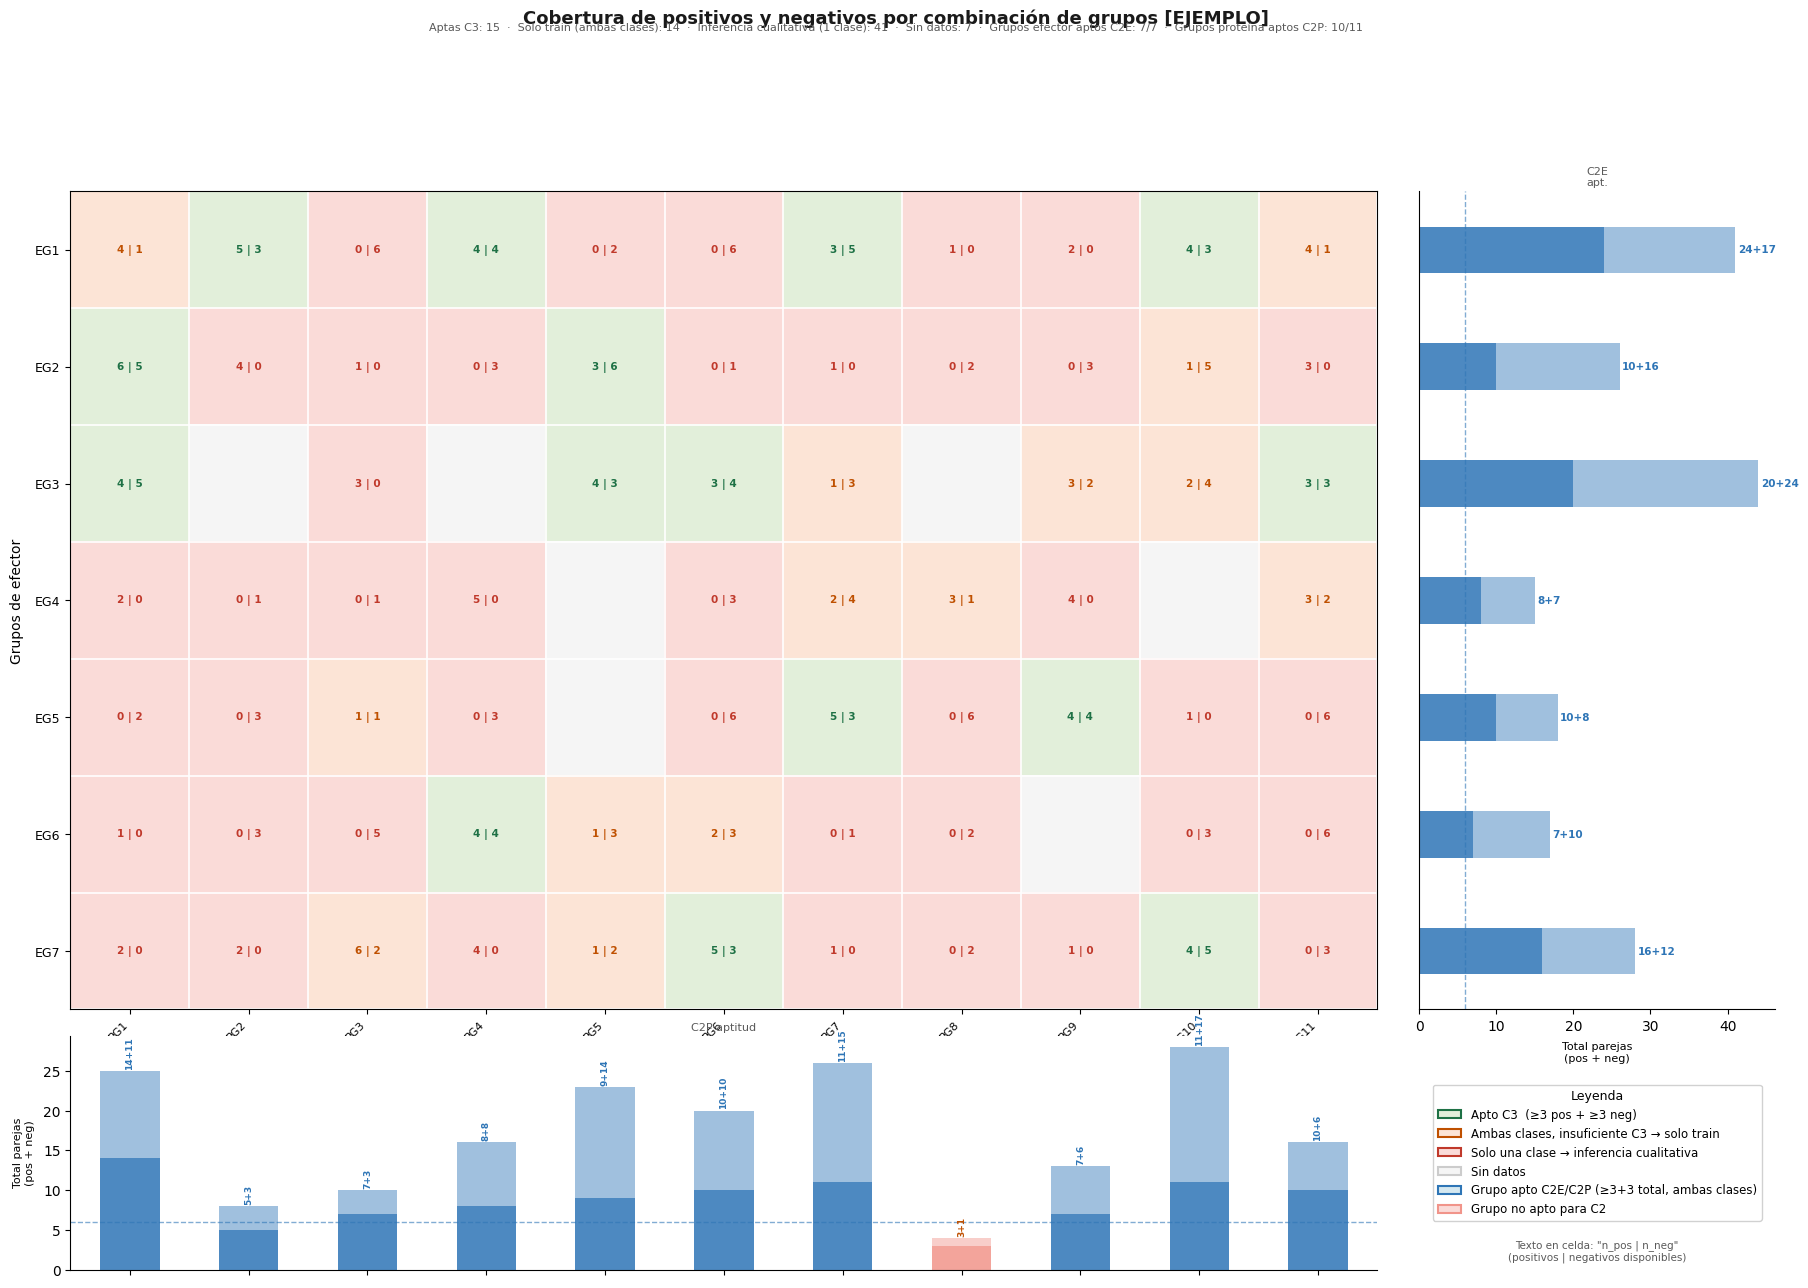

In [14]:
%run /home/jovyan/TFG/plot_coverage_heatmap.py

La ejecutamos ahora con nuestros datos.

/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: imagenes/heatmap_pos_neg_g13sep.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 16 combinaciones aptas (verde)
  Train only: 14 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 4 combinaciones (rojo, solo 1 clase)
  Sin datos: 1 combinaciones (gris)
  C2E : 7/7 grupos de efector aptos
  C2P : 5/5 grupos de proteína aptos
──────────────────────────────────────────────────────────────────



(<Figure size 2200x1400 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 16,
  'n_cells_train_only': 14,
  'n_cells_one_class': 4,
  'n_cells_empty': 1,
  'n_effector_groups_C2E': 7,
  'n_protein_groups_C2P': 5,
  'effector_apt_C2E': ['Cluster_6',
   'Cluster_0',
   'Cluster_1',
   'Cluster_4',
   'Cluster_3',
   'Cluster_2',
   'Cluster_5'],
  'effector_nonapt_C2E': [],
  'protein_apt_C2P': ['Cluster_3',
   'Cluster_4',
   'Cluster_1',
   'Cluster_2',
   'Cluster_0'],
  'protein_nonapt_C2P': []})

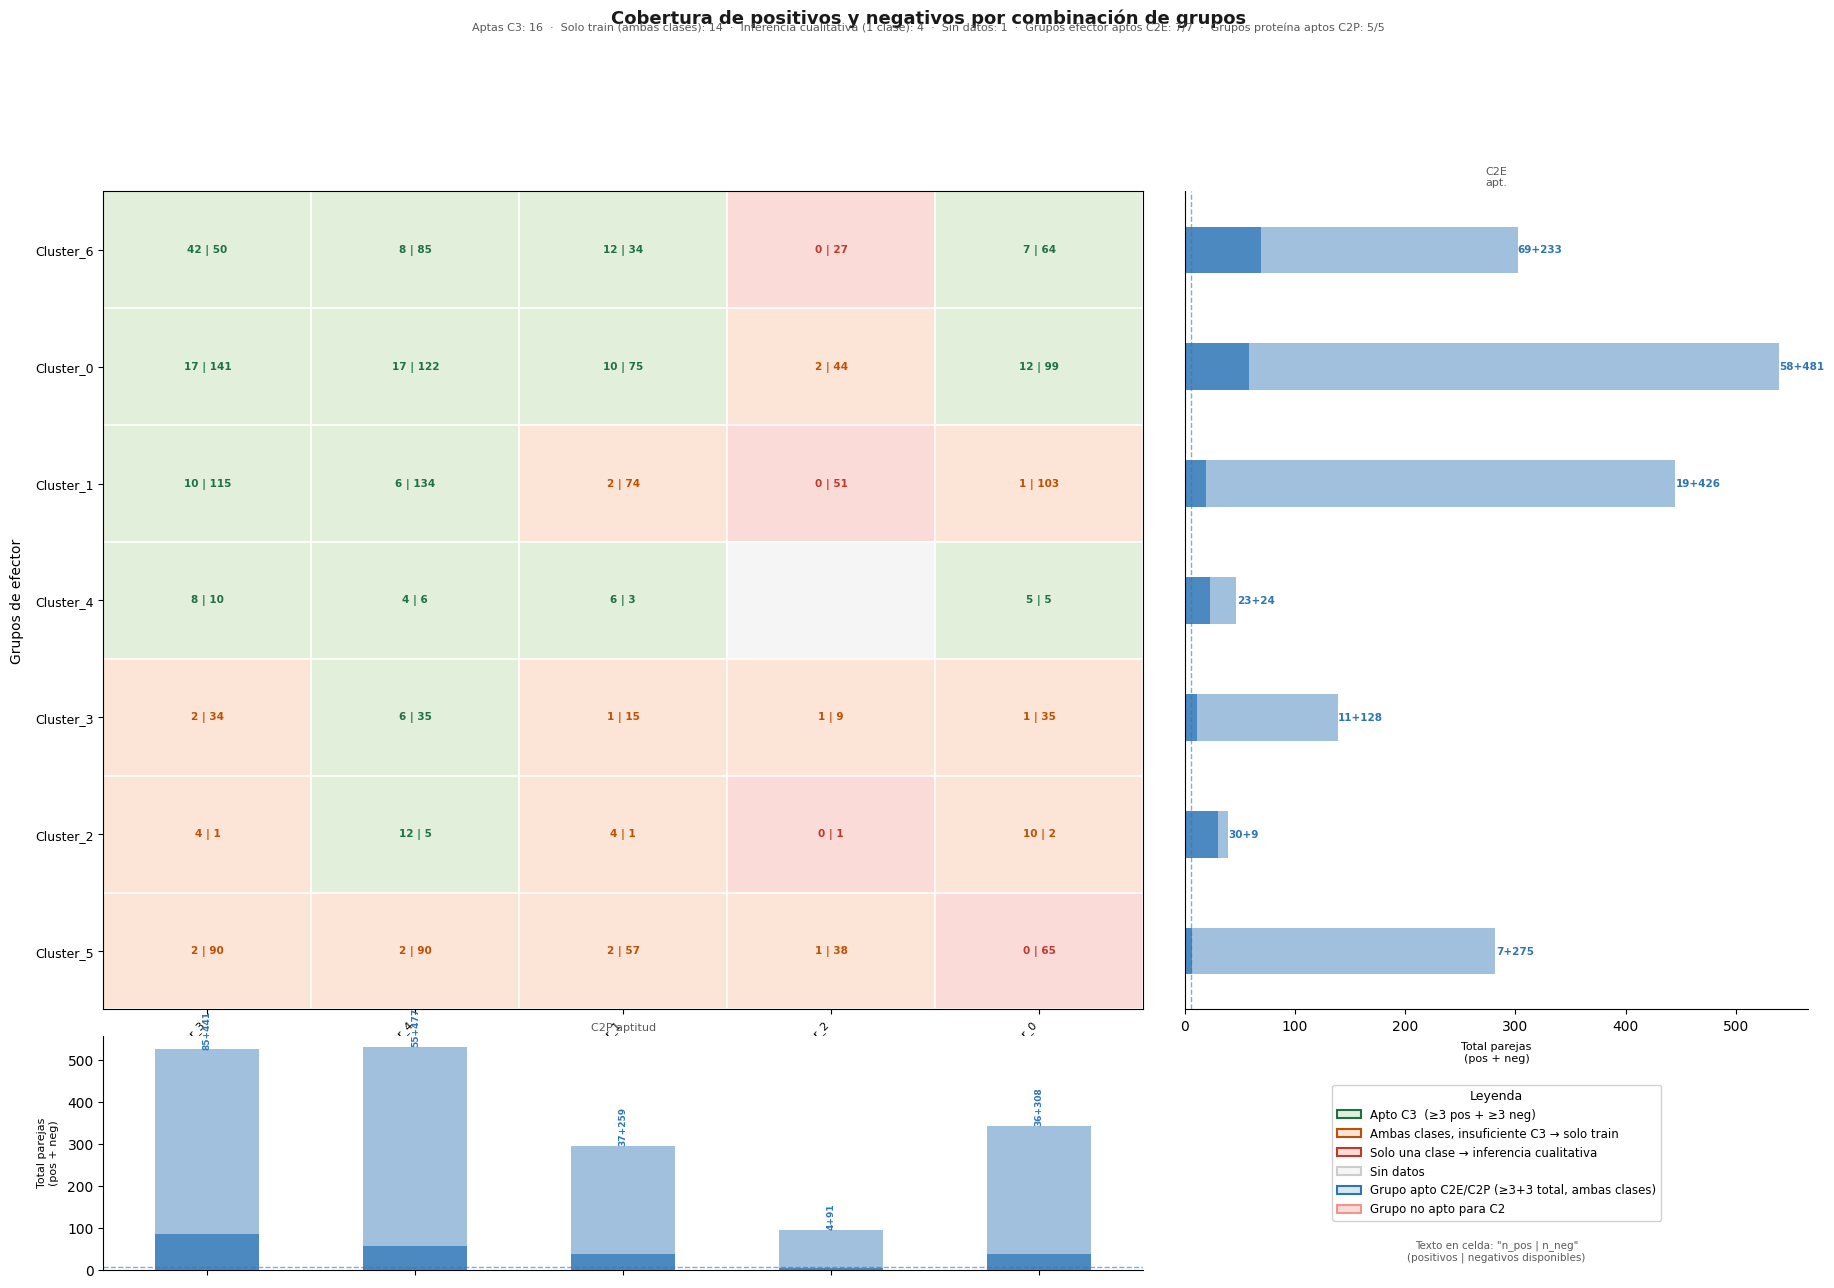

In [15]:
# Ya teníamos el dataframe con las interacciones positivas
# Añadimos las negativas definidas por el umbral
neg_interactions = new_interactions[new_interactions["Interaction_Score"] <= 0.1]
pos_neg_interactions = pd.concat([pos_interactions, neg_interactions])
pos_neg_interactions["Label"] = pos_neg_interactions["Is_Connected"].astype(int)

plot_coverage_heatmap(
    df=pos_neg_interactions, 
    effector_group_col="Effector_Group", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="imagenes/heatmap_pos_neg_g13sep.png"
)

#### Distribución en el nivel C3 (cogemos verdes y naranjas)

In [16]:
# Obtenemos el conjunto de combinaciones que tienen positivos
pos_keys = set(pos_interactions.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# Obtenemos el conjunto de combinaciones que tienen negativos
neg_keys = set(neg_interactions.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# La INTERSECCIÓN son las celdas que tienen AL MENOS UNO de cada (Verde/Naranja)
mixed_cells = pos_keys.intersection(neg_keys)

print(f"Total de celdas mixtas encontradas: {len(mixed_cells)}")

# Filtrar Negativos
neg_interactions_c3 = neg_interactions[
    neg_interactions.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

# Filtrar Positivos
pos_interactions_c3 = pos_interactions[
    pos_interactions.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

train_interactions = pd.concat([pos_interactions_c3, neg_interactions_c3], ignore_index=True)

# 3. Verificación
print(f"Negativos originales: {len(neg_interactions)}")
print(f"Negativos en zonas Verde/Naranja: {len(neg_interactions_c3)}")
print(f"Positivos originales: {len(pos_interactions)}")
print(f"Positivos en zonas Verde/Naranja: {len(pos_interactions_c3)}")

Total de celdas mixtas encontradas: 30
Negativos originales: 1720
Negativos en zonas Verde/Naranja: 1576
Positivos originales: 217
Positivos en zonas Verde/Naranja: 217


Estos datos de entrenamiento del nivel C3 van a ser los mismos para el resto de niveles también, por lo que lo guardamos en un csv para poder acceder a ellos más tarde.

In [17]:
#train_interactions.to_csv("Interacciones_Entrenamiento_CV_g13sep.csv", index=False)

##### Distribución de proteínas individuales en el Nivel C3

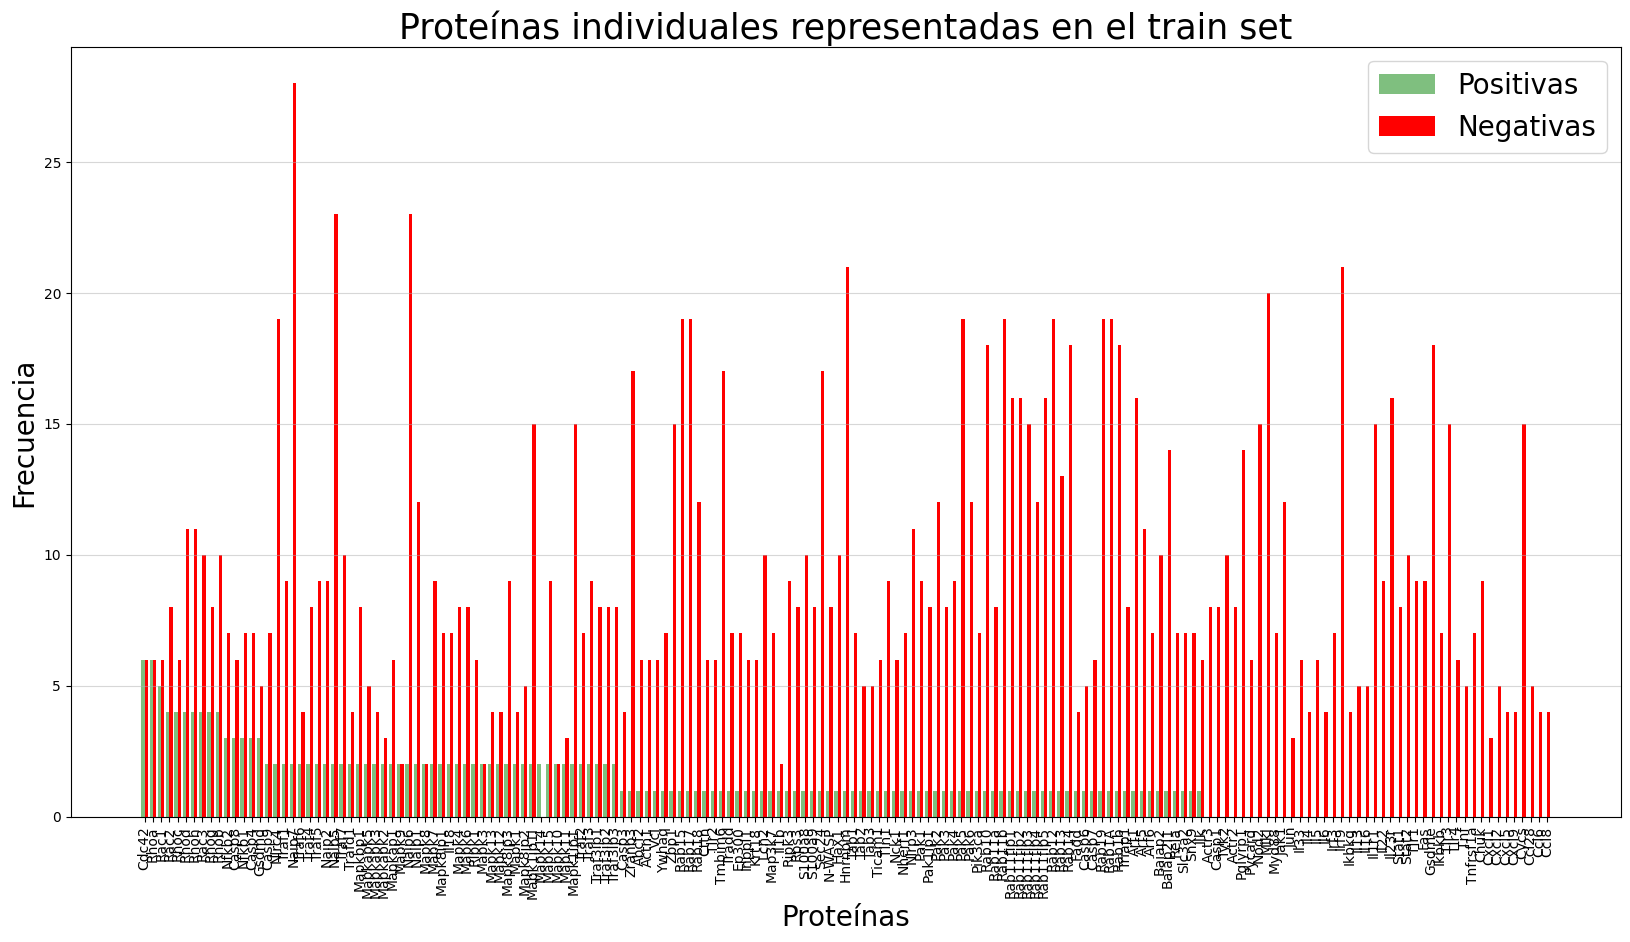

In [18]:
pos_prot_nivelc3 = pos_interactions_c3["Protein"]
neg_prot_nivelc3 = neg_interactions_c3["Protein"]
pos_prot_freq_nivelc3 = pos_prot_nivelc3.value_counts()
neg_prot_freq_nivelc3 = neg_prot_nivelc3.value_counts()
draw_group_distribution(pos_prot_freq_nivelc3, neg_prot_freq_nivelc3, 'imagenes/distribucion_prot_pos_neg_train_nivelc3.png', pos_color="green", neg_color="red", title="Proteínas individuales representadas en el train set", x_label="Proteínas")

##### Distribución de efectores individuales en el Nivel C3

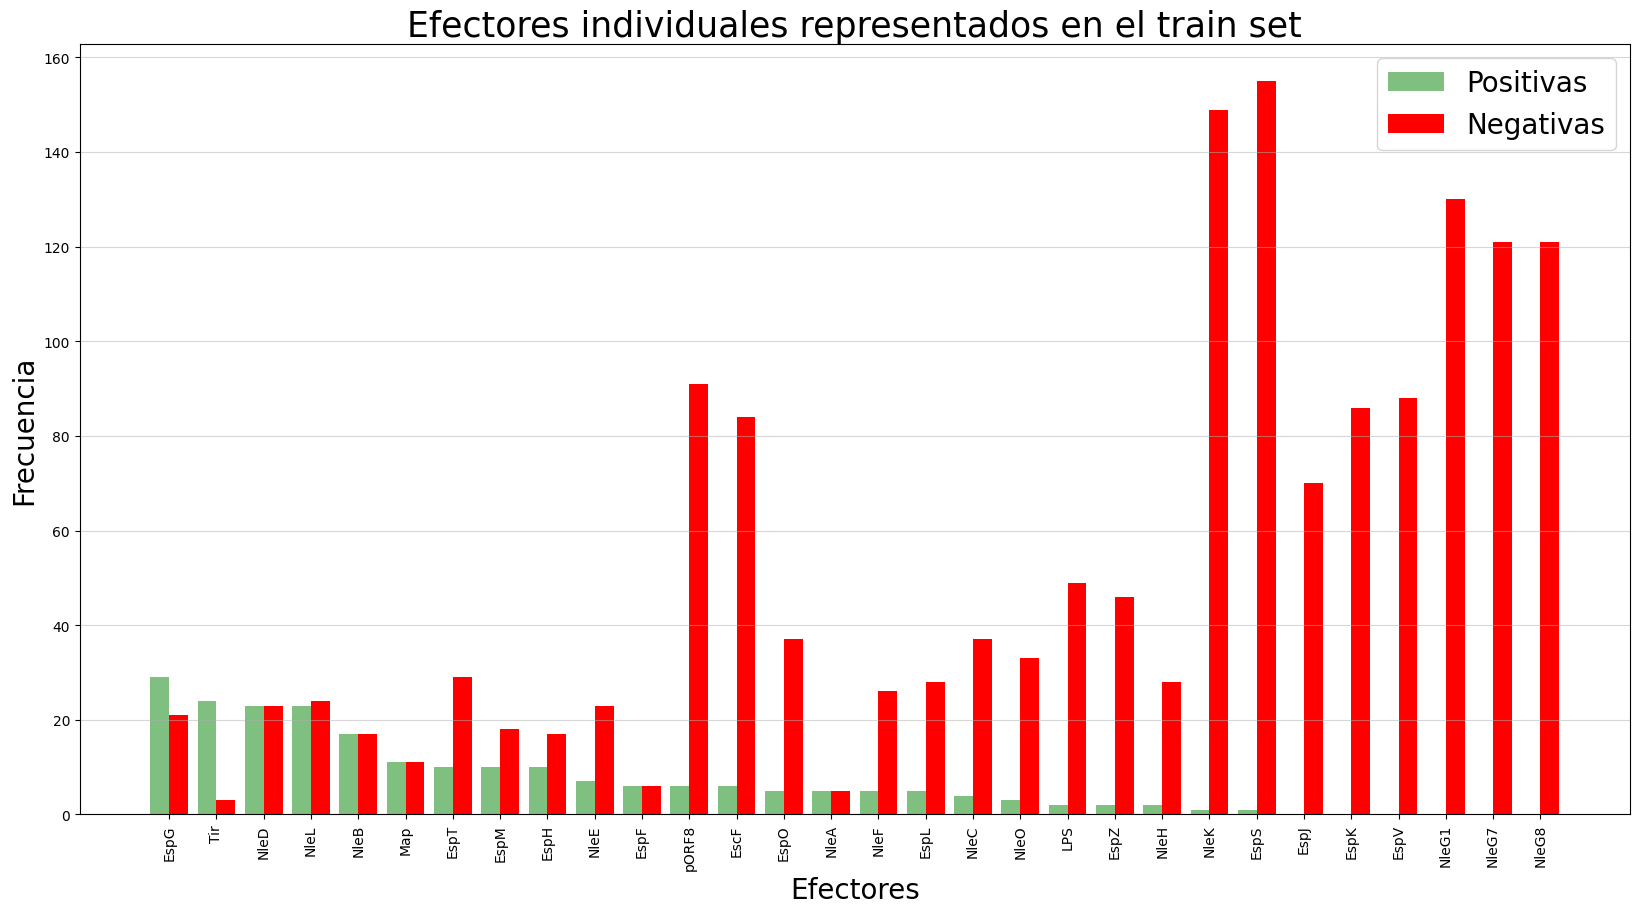

In [19]:
pos_ef_nivelc3 = pos_interactions_c3["Effector"]
neg_ef_nivelc3 = neg_interactions_c3["Effector"]
pos_ef_freq_nivelc3 = pos_ef_nivelc3.value_counts()
neg_ef_freq_nivelc3 = neg_ef_nivelc3.value_counts()
draw_group_distribution(pos_ef_freq_nivelc3, neg_ef_freq_nivelc3, 'imagenes/distribucion_ef_pos_neg_train_nivelc3_g13sep.png', pos_color="green", neg_color="red", title="Efectores individuales representados en el train set", x_label="Efectores")

#### Reajuste de datos para el nivel estricto

Nos quedamos con el nivel c3 (grupos de proteínas y efectores que al menos tienen una representación tanto en positivo como en negativo) y filtramos para que entre las celdas elegidas se eliminen todas aquellas parejas cuyos efectores o proteínas no aparezcan representadas individualmente en positivo y negativo.

In [20]:
# 1. Bucle de Estabilidad (Garantiza que Proteína Y Efector sean mixtos a la vez)
def filtrar_mixtos_estricto(df):
    pasada = 0
    while True:
        n_inicial = len(df)
        
        # Identificar quiénes tienen representación en AMBOS labels EN ESTE MOMENTO
        # Agrupamos y contamos cuántos labels únicos tiene cada uno (debe ser 2: 0 y 1)
        prot_counts = df.groupby('Protein')['Label'].nunique()
        ef_counts = df.groupby('Effector')['Label'].nunique()
        
        prot_mixtas = prot_counts[prot_counts == 2].index
        ef_mixtos = ef_counts[ef_counts == 2].index
        
        # Aplicar el filtro simultáneo
        df = df[df['Protein'].isin(prot_mixtas) & df['Effector'].isin(ef_mixtos)]
        
        pasada += 1
        n_final = len(df)
        print(f"Pasada {pasada}: {n_inicial} filas -> {n_final} filas")
        
        if n_inicial == n_final:
            print("✅ Estabilidad alcanzada. Todos los individuos son mixtos.")
            break
    return df

# Ejecutar el filtro
train_interactions["Label"] = train_interactions["Is_Connected"].astype(int)
# Antes de ejecutar el filtro elimino los efectores EspS y NleK por ser los que tienen más de 100 interacciones
# negativas y solo una positiva
#train_interactions = train_interactions[~train_interactions["Effector"].isin(['EspS', 'NleK'])]
pos_neg_interactions_estricto = filtrar_mixtos_estricto(train_interactions)

# Quitamos los efectores EspS y NleK por ser los que tienen más de 100 negativas y solo 1 positiva


# 2. Extraer los subconjuntos usando LA MISMA VARIABLE FILTRADA
pos_interactions_estricto = pos_neg_interactions_estricto[pos_neg_interactions_estricto["Label"] == 1].copy()
neg_interactions_estricto = pos_neg_interactions_estricto[pos_neg_interactions_estricto["Label"] == 0].copy()

# 3. Verificación matemática (Si esto sale 0, es físicamente imposible que haya barras de un solo color)
solo_un_bando = pos_neg_interactions_estricto.groupby('Protein')['Label'].nunique()
print(f"Proteínas con un solo bando: {(solo_un_bando < 2).sum()}")

Pasada 1: 1793 filas -> 990 filas
Pasada 2: 990 filas -> 989 filas
Pasada 3: 989 filas -> 989 filas
✅ Estabilidad alcanzada. Todos los individuos son mixtos.
Proteínas con un solo bando: 0


/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: imagenes/heatmap_pos_neg_nivelc3_g13sep_con_EspS_NleK.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 15 combinaciones aptas (verde)
  Train only: 11 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 3 combinaciones (rojo, solo 1 clase)
  Sin datos: 6 combinaciones (gris)
  C2E : 7/7 grupos de efector aptos
  C2P : 5/5 grupos de proteína aptos
──────────────────────────────────────────────────────────────────



(<Figure size 2200x1400 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 15,
  'n_cells_train_only': 11,
  'n_cells_one_class': 3,
  'n_cells_empty': 6,
  'n_effector_groups_C2E': 7,
  'n_protein_groups_C2P': 5,
  'effector_apt_C2E': ['Cluster_6',
   'Cluster_0',
   'Cluster_1',
   'Cluster_3',
   'Cluster_2',
   'Cluster_4',
   'Cluster_5'],
  'effector_nonapt_C2E': [],
  'protein_apt_C2P': ['Cluster_3',
   'Cluster_4',
   'Cluster_1',
   'Cluster_2',
   'Cluster_0'],
  'protein_nonapt_C2P': []})

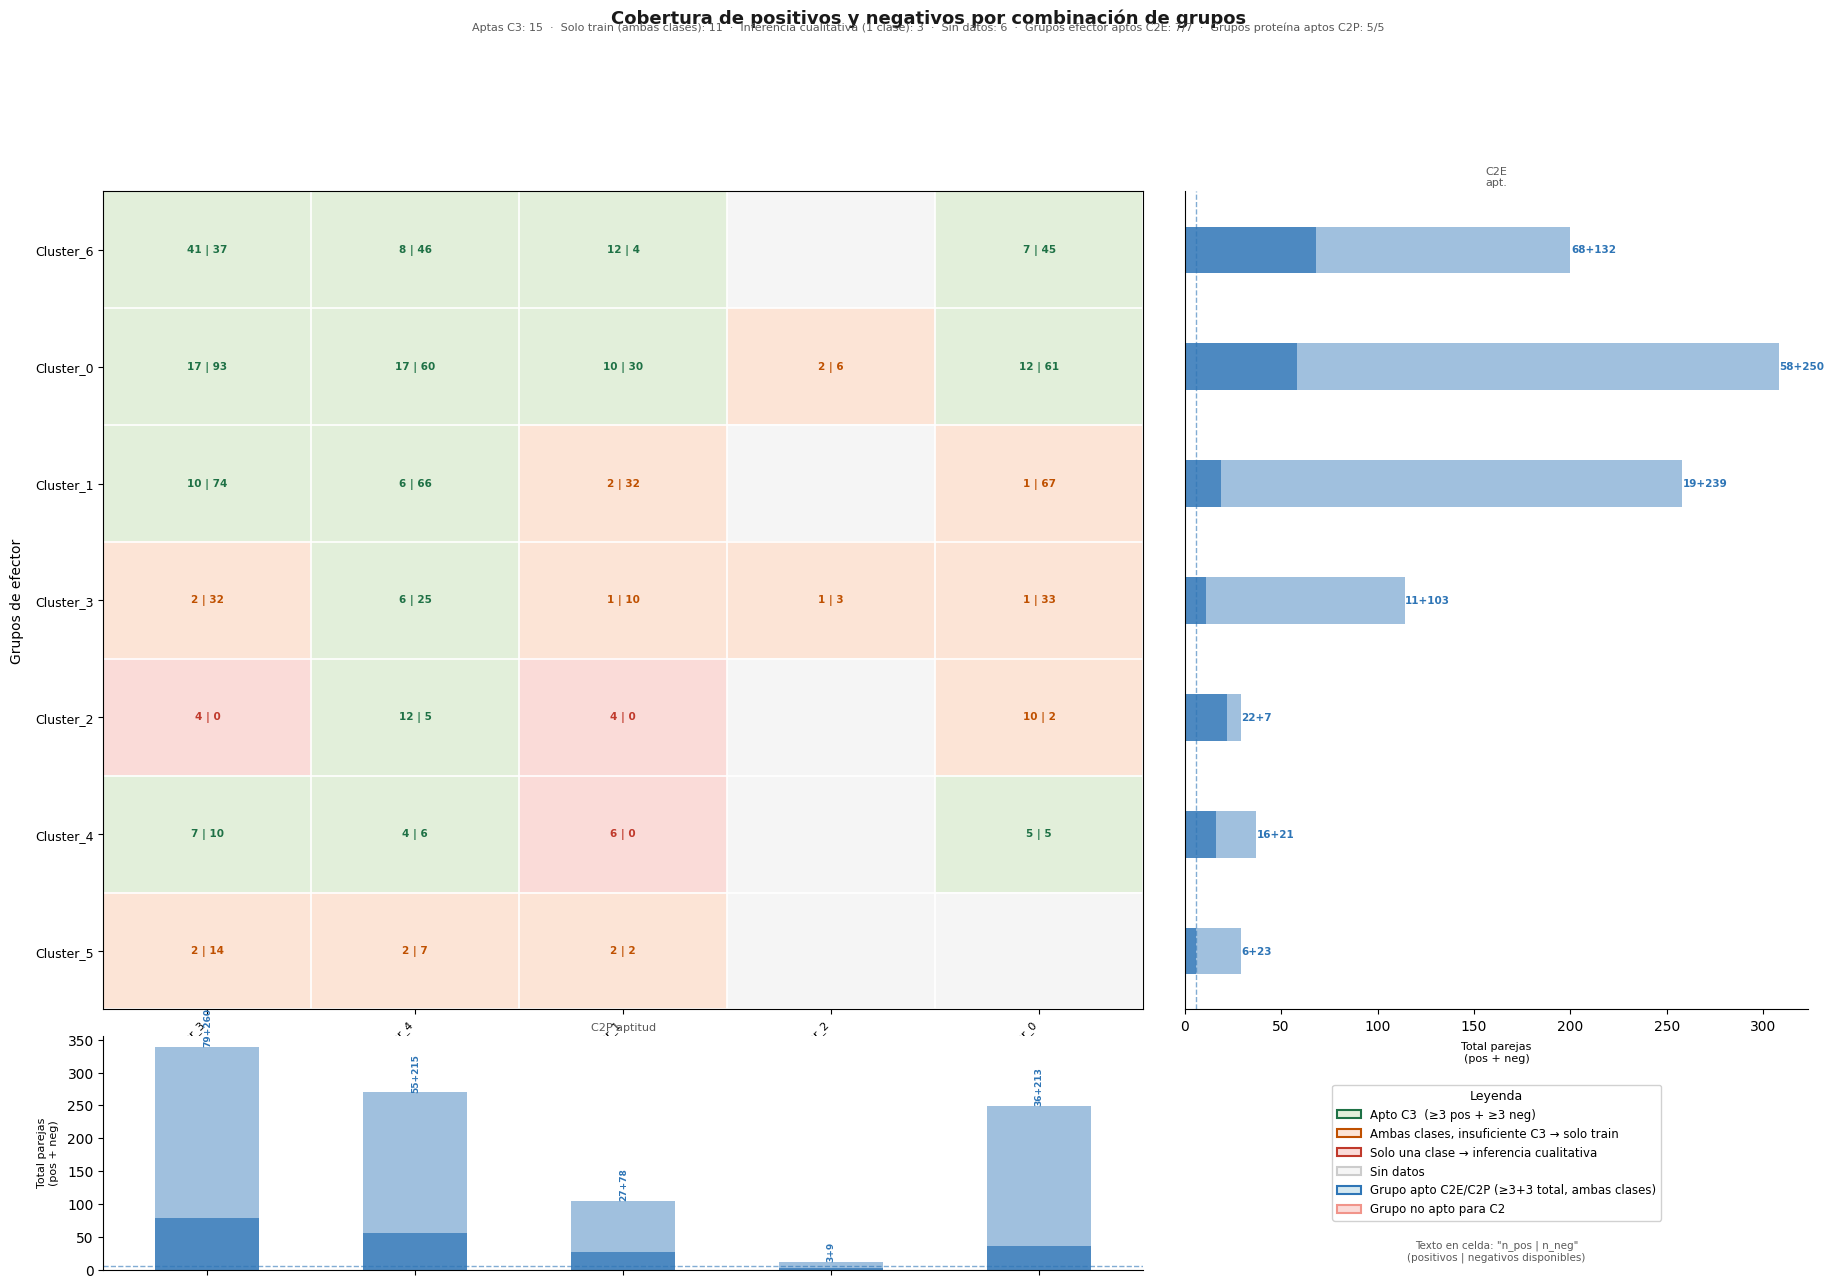

In [21]:
plot_coverage_heatmap(
    df=pos_neg_interactions_estricto, 
    effector_group_col="Effector_Group", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="imagenes/heatmap_pos_neg_nivelc3_g13sep_con_EspS_NleK.png"
)

## Distribución en el Nivel C3 estricto

Buscamos quedarnos con las casillas verdes y naranjas de nuevo, pero esta vez esas casillas no incluirán proteínas ni efectores que no estén presentes tanto en positivo como en negativo. Sin embargo, al eliminar casillas rojas, puede ocurrir que se esté eliminando además la única pareja positiva de un determinado efector, por ejemplo. Por eso hay que hacer un filtro adicional que recorra las celdas y, si al eliminar una roja se ha eliminado el único representante de un tipo de una proteína o efector, que se elimine también su equivalente.

In [22]:
# Obtenemos el conjunto de combinaciones que tienen positivos
pos_keys = set(pos_interactions_estricto.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# Obtenemos el conjunto de combinaciones que tienen negativos
neg_keys = set(neg_interactions_estricto.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# La INTERSECCIÓN son las celdas que tienen AL MENOS UNO de cada (Verde/Naranja)
mixed_cells = pos_keys.intersection(neg_keys)

print(f"Total de celdas mixtas encontradas: {len(mixed_cells)}")

# Filtrar Negativos
neg_interactions_estricto = neg_interactions_estricto[
    neg_interactions_estricto.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

# Filtrar Positivos
pos_interactions_estricto = pos_interactions_estricto[
    pos_interactions_estricto.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

train_interactions_filtro_estricto = pd.concat([pos_interactions_estricto, neg_interactions_estricto], ignore_index=True)

# 3. Verificación
print(f"Negativos originales: {len(neg_interactions)}")
print(f"Negativos en zonas Verde/Naranja: {len(neg_interactions_estricto)}")
print(f"Positivos originales: {len(pos_interactions)}")
print(f"Positivos en zonas Verde/Naranja: {len(pos_interactions_estricto)}")

Total de celdas mixtas encontradas: 26
Negativos originales: 1720
Negativos en zonas Verde/Naranja: 775
Positivos originales: 217
Positivos en zonas Verde/Naranja: 200


In [23]:
# Repetimos una función que nos vuelva a dejar solo las proteínas y efectores que tengan tanto representación positiva como negativa
# Es necesario repetir esta función por el motivo que se ha expuesto arriba

def filtrar_celdas_y_mixtos_estricto(df):
    pasada = 0
    while True:
        n_inicial = len(df)
        
        # 1. Identificar CELDAS mixtas (Pareja Protein_Group - Effector_Group)
        # Solo sobreviven parejas de grupos que tienen Label 0 y Label 1
        celdas_counts = df.groupby(['Protein_Group', 'Effector_Group'])['Label'].nunique()
        celdas_mixtas = celdas_counts[celdas_counts == 2].index
        
        # Aplicamos filtro de celdas
        # Creamos una tupla para poder comparar con el índice de celdas_mixtas
        df = df[df.set_index(['Protein_Group', 'Effector_Group']).index.isin(celdas_mixtas)]
        
        # 2. Re-validar INDIVIDUOS mixtos (Proteínas y Efectores individuales)
        # Al borrar celdas, puede que un individuo pierda su último 0 o su último 1
        prot_counts = df.groupby('Protein')['Label'].nunique()
        ef_counts = df.groupby('Effector')['Label'].nunique()
        
        prot_mixtas = prot_counts[prot_counts == 2].index
        ef_mixtos = ef_counts[ef_counts == 2].index
        
        df = df[df['Protein'].isin(prot_mixtas) & df['Effector'].isin(ef_mixtos)]
        
        pasada += 1
        n_final = len(df)
        print(f"Pasada {pasada}: {n_inicial} -> {n_final} filas")
        
        if n_inicial == n_final:
            print("✅ Estabilidad total alcanzada: Celdas e individuos son mixtos.")
            break
    return df

# Ejecución sobre tus datos estricto del código anterior
pos_neg_interactions_final = filtrar_celdas_y_mixtos_estricto(pos_neg_interactions_estricto)

# Separar para tu verificación final
pos_interactions_f = pos_neg_interactions_final[pos_neg_interactions_final["Label"] == 1]
neg_interactions_f = pos_neg_interactions_final[pos_neg_interactions_final["Label"] == 0]


Pasada 1: 989 -> 963 filas
Pasada 2: 963 -> 963 filas
✅ Estabilidad total alcanzada: Celdas e individuos son mixtos.


Guardamos los datos para usarlos después.

In [24]:
pos_neg_interactions_final.to_csv("Interacciones_Entrenamiento_CV_estricto_kmeans_con_EspS_NleK.csv", index=False)

$\textbf{Repetición del heatmap}$

/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: imagenes/heatmap_pos_neg_nivelc3_g13sep_filtro_estricto_con_EspS_NleK.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 15 combinaciones aptas (verde)
  Train only: 11 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 0 combinaciones (rojo, solo 1 clase)
  Sin datos: 9 combinaciones (gris)
  C2E : 7/7 grupos de efector aptos
  C2P : 5/5 grupos de proteína aptos
──────────────────────────────────────────────────────────────────



(<Figure size 2200x1400 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 15,
  'n_cells_train_only': 11,
  'n_cells_one_class': 0,
  'n_cells_empty': 9,
  'n_effector_groups_C2E': 7,
  'n_protein_groups_C2P': 5,
  'effector_apt_C2E': ['Cluster_6',
   'Cluster_0',
   'Cluster_1',
   'Cluster_3',
   'Cluster_2',
   'Cluster_5',
   'Cluster_4'],
  'effector_nonapt_C2E': [],
  'protein_apt_C2P': ['Cluster_3',
   'Cluster_4',
   'Cluster_1',
   'Cluster_2',
   'Cluster_0'],
  'protein_nonapt_C2P': []})

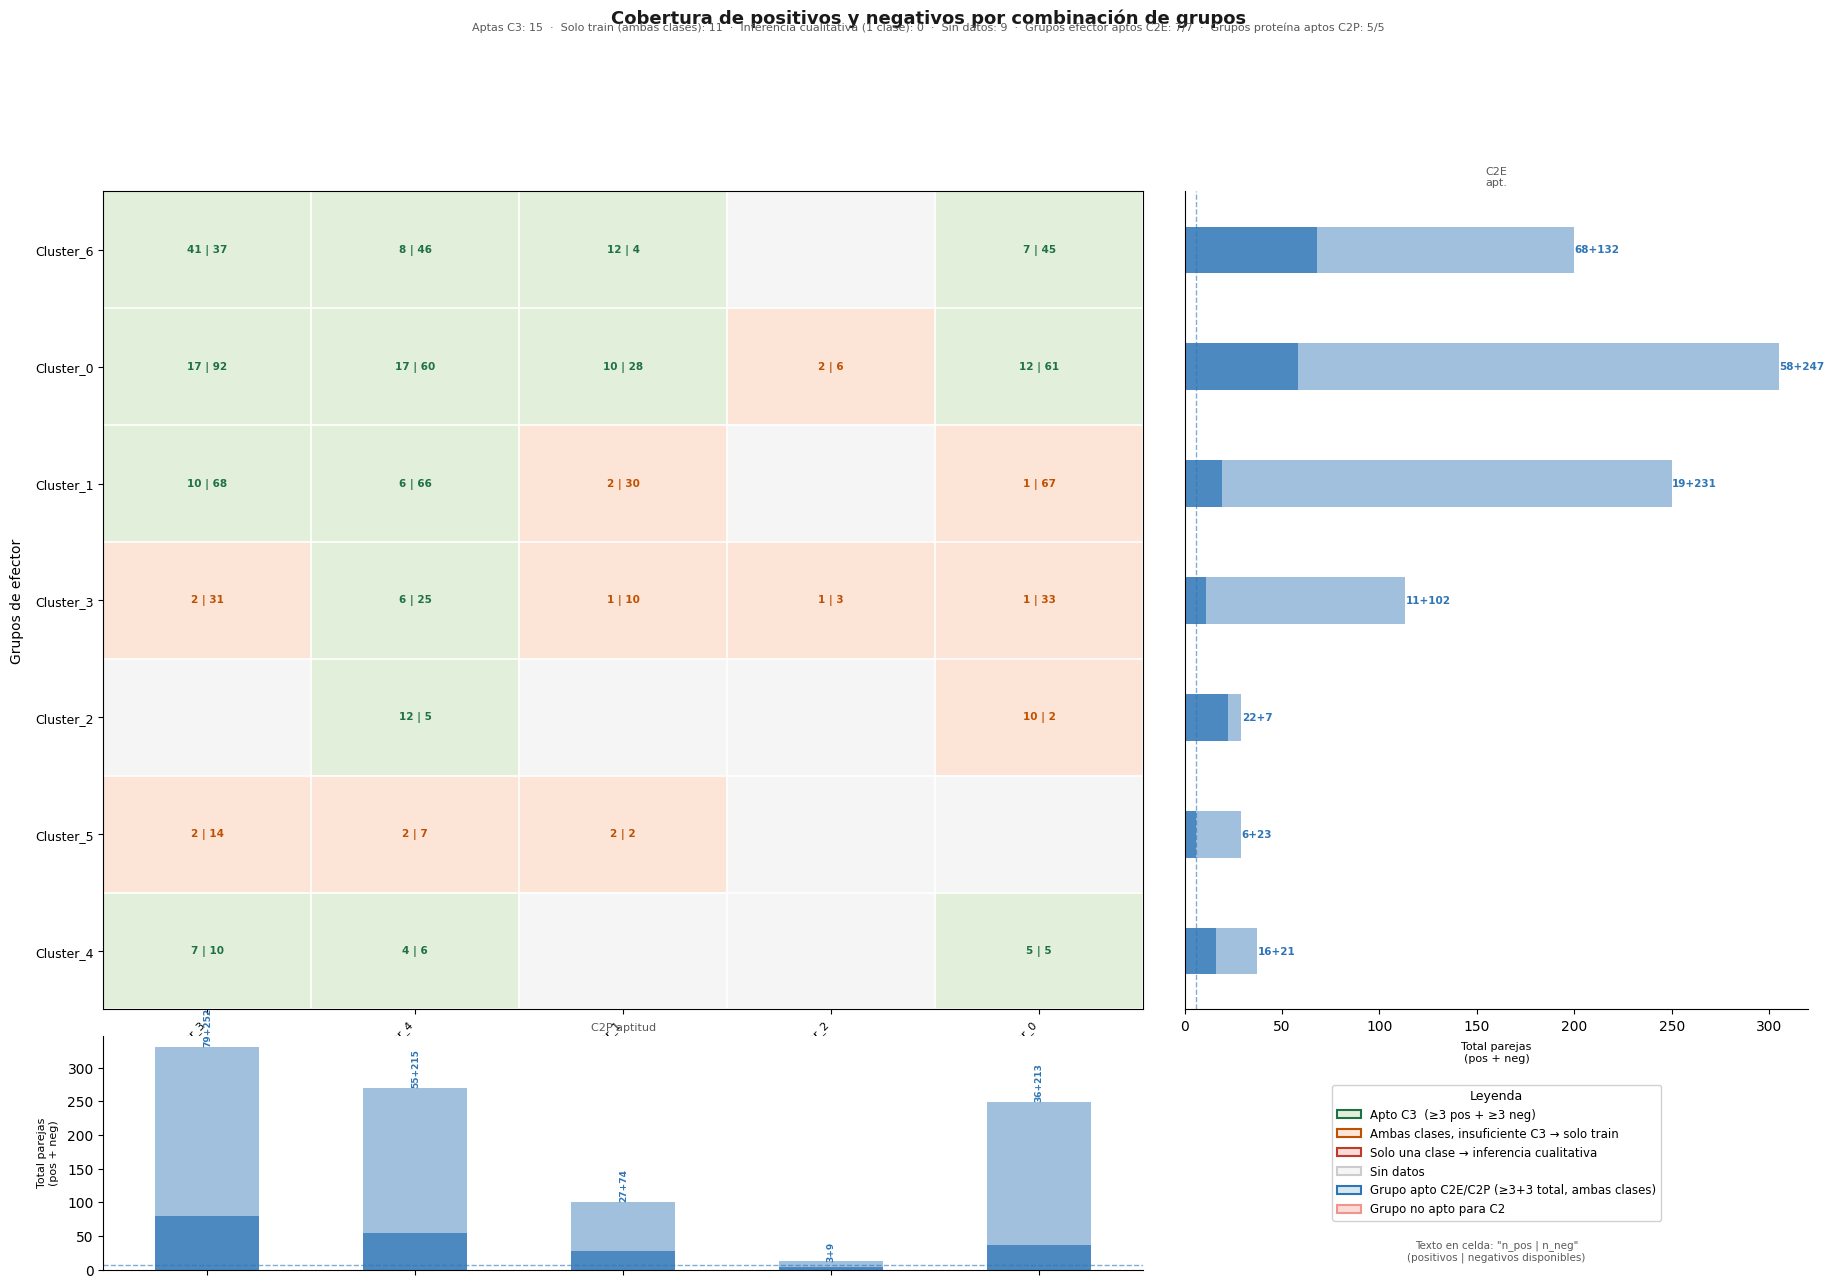

In [25]:
plot_coverage_heatmap(
    df=pos_neg_interactions_final, 
    effector_group_col="Effector_Group", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="imagenes/heatmap_pos_neg_nivelc3_g13sep_filtro_estricto_con_EspS_NleK.png"
)

Repetimos las distribuciones de proteínas y efectores individuales

##### Distribución de proteínas individuales en el nivel C3 tras filtrar aquellas que no tienen representación positiva y negativa

Total de proteínas positivas: 200
Total de proteínas negativas: 763
Total de proteínas en el entrenamiento: 200 + 763 = 963


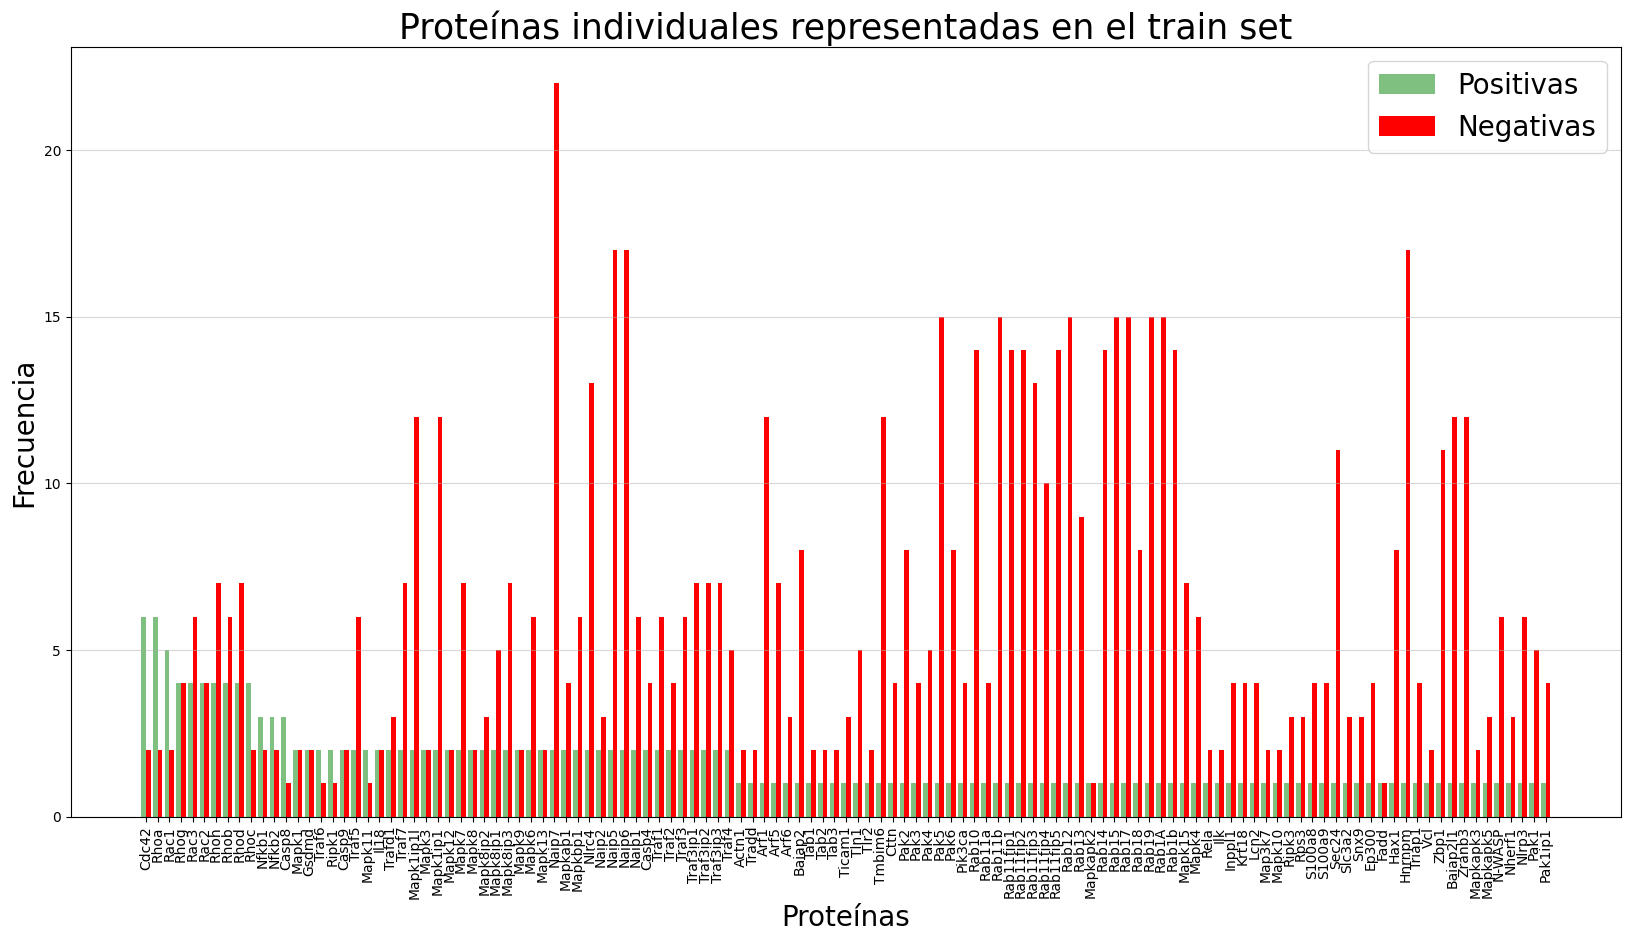

In [26]:
pos_prot_estricto = pos_interactions_f["Protein"]
print(f"Total de proteínas positivas: {len(pos_prot_estricto)}")
neg_prot_estricto = neg_interactions_f["Protein"]
print(f"Total de proteínas negativas: {len(neg_prot_estricto)}")
print(f"Total de proteínas en el entrenamiento: {len(pos_prot_estricto)} + {len(neg_prot_estricto)} = {len(pos_prot_estricto) + len(neg_prot_estricto)}")
pos_prot_freq_estricto = pos_prot_estricto.value_counts()
neg_prot_freq_estricto = neg_prot_estricto.value_counts()
draw_group_distribution(pos_prot_freq_estricto, neg_prot_freq_estricto, 'imagenes/distribucion_prot_pos_neg_train_nivelc3_filtrado_g13sep.png', pos_color="green", neg_color="red", title="Proteínas individuales representadas en el train set", x_label="Proteínas")

##### Distribución de efectores individuales en el nivel C3 tras filtrar aquellos que no tenían representación positiva y negativa a la vez

Total de efectores positivos: 200
Total de efectores negativos: 763
Total de efectores en el entrenamiento: 200 + 763 = 963


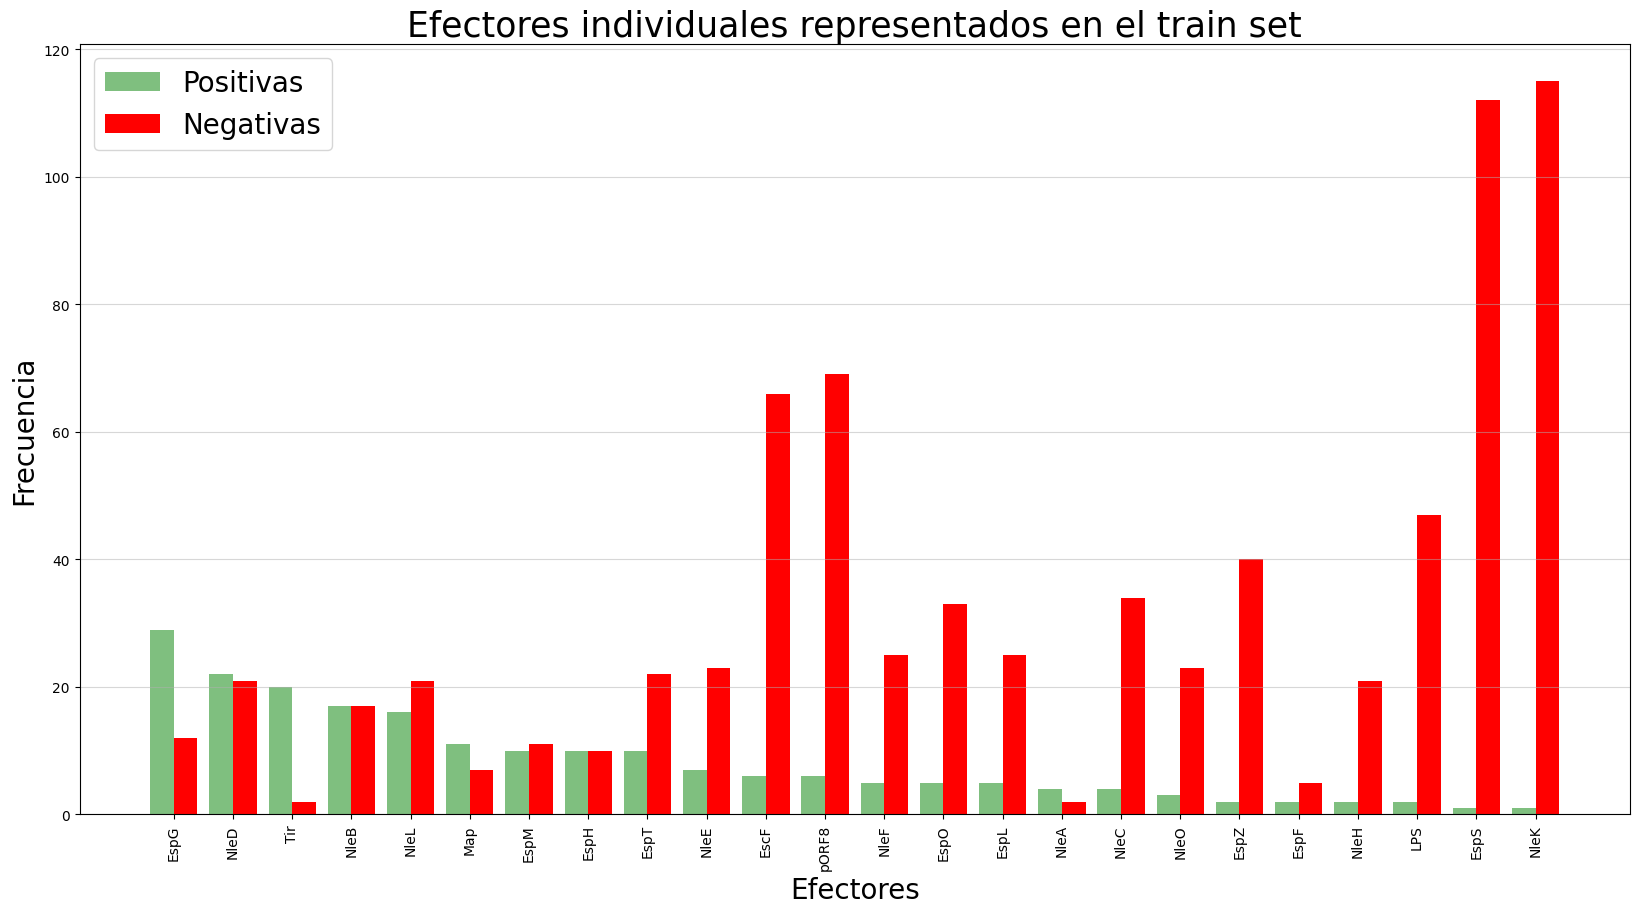

In [27]:
pos_ef_estricto = pos_interactions_f["Effector"]
print(f"Total de efectores positivos: {len(pos_ef_estricto)}")
neg_ef_estricto = neg_interactions_f["Effector"]
print(f"Total de efectores negativos: {len(neg_ef_estricto)}")
print(f"Total de efectores en el entrenamiento: {len(pos_ef_estricto)} + {len(neg_ef_estricto)} = {len(pos_ef_estricto) + len(neg_ef_estricto)}")
pos_ef_freq_estricto = pos_ef_estricto.value_counts()
neg_ef_freq_estricto = neg_ef_estricto.value_counts()
draw_group_distribution(pos_ef_freq_estricto, neg_ef_freq_estricto, 'imagenes/distribucion_ef_pos_neg_train_nivelc3_filtrado_g13sep.png', pos_color="green", neg_color="red", title="Efectores individuales representados en el train set", x_label="Efectores")